# Simulation of LUCJ circuits

In [1]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf

import qiskit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
from qiskit.quantum_info import Statevector, SparsePauliOp, DensityMatrix

## Parameters

In [2]:
atom: str = "H"
natoms: int = 2
nlayers: int = 1  # Number of layers in the ansatz.

damping: float = 0.01
cutoff: float = 1e-16

## Problem defintion

### Molecule

In [3]:
def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.
    
    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

In [4]:
# Specify molecule properties
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

# Compute exact energy using FCI
# reference_energy = cas.run().e_tot

print(f"norb = {norb}")
print(f"nelec = {nelec}")

converged SCF energy = -1.07358293078636
norb = 2
nelec = (1, 1)


## Circuit construction

In [5]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

E(CCSD) = -1.108873060181064  E_corr = -0.03529012939470327


In [6]:
coupling_map = CouplingMap.from_grid(
    num_rows=int(np.ceil(np.sqrt(2 * norb))),
    num_columns=int(np.ceil(np.sqrt(2 * norb)))
)
backend = GenericBackendV2(
    coupling_map.size(),
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

In [7]:
pairs_aa = [(p, p + 1) for p in range(norb - 1)]
pairs_ab = [(p, p) for p in range(norb)]  # None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

In [8]:
# Create pass manager
try:
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="square",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )
    print("Unable to generate ffsim pass manager")
except RuntimeError:
    pass_manager = None

print("pairs_aa:", pairs_aa)
print("pairs_ab:", pairs_ab)

Unable to generate ffsim pass manager
pairs_aa: [(0, 1)]
pairs_ab: [(0, 0), (1, 1)]


In [9]:
# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=nlayers,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell from running
    # too long. Removing this line may improve results.
    options=dict(maxiter=1000),
)

qubits = qiskit.QuantumRegister(2 * norb, name="q")
circuit = qiskit.QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)

In [10]:
if pass_manager is not None:
    compiled = pass_manager.run(circuit)
else:
    compiled = qiskit.transpile(circuit, backend=backend, optimization_level=3)

In [11]:
print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

Number of qubits: 4
Gate counts: OrderedDict([('xx_plus_yy', 4), ('cp', 4), ('p', 4), ('x', 2)])


In [12]:
compiled.draw(fold=-1)

┌────────────────────┐                                                              ┌───────────────────┐     ┌─────────┐                
q_3 -> 0 ─────┤0                   ├───────────────────────■─────────────────────────■────────────┤0                  ├─────┤ P(3π/4) ├────────────────
              │                    │┌────────────────────┐ │                         │P(-0.14919) │                   │┌────┴─────────┴────┐┌─────────┐
q_1 -> 1 ─────┤  (XX+YY)(π/2,-π/2) ├┤0                   ├─┼────────────■────────────■────────────┤  (XX+YY)(π/2,π/2) ├┤0                  ├┤ P(3π/4) ├
         ┌───┐│                    ││                    │ │P(0.20886)  │                         │                   ││                   │└┬───────┬┘
q_2 -> 2 ┤ X ├┤1                   ├┤  (XX+YY)(π/2,-π/2) ├─■────────────┼────────────■────────────┤1                  ├┤  (XX+YY)(π/2,π/2) ├─┤ P(-π) ├─
         ├───┤└────────────────────┘│                    │              │P(0.20886)  │P(-0.14919) └───────────────────┘│                   │ ├───────┤ 
q_0 -> 3 ┤ X ├──────────────────────┤1                   ├──────────────■────────────■─────────────────────────────────┤1                  ├─┤ P(-π) ├─
         └───┘                      └────────────────────┘                                                             └───────────────────┘ └───────┘

## Observable definition

In [13]:
observables = [
    SparsePauliOp("ZZ" + "I" * (compiled.num_qubits - 2)),
    SparsePauliOp("I" * (compiled.num_qubits // 2) + "ZZ" + "I" * (compiled.num_qubits - 2 - compiled.num_qubits // 2)),
    SparsePauliOp("I" * (compiled.num_qubits - 2) + "ZZ")
]

### Exact values

In [14]:
if compiled.num_qubits <= 20:
    expectation_values_exact = []
    for observable in observables:
        statevector = Statevector(compiled)
        sv_expectation_value = statevector.expectation_value(observable).real
        print(sv_expectation_value)
        expectation_values_exact.append(sv_expectation_value)

1.0
1.0
1.0


### Noisy values

In [15]:
import math
from qiskit.converters import circuit_to_dag
from qiskit.quantum_info import Kraus

In [16]:
p_depol = 0.75 * (1 - math.exp(-damping))
s = math.sqrt
depol_kraus = Kraus([
    s(1 - p_depol) * np.eye(2),
    s(p_depol / 3) * np.array([[0, 1], [1, 0]]),
    s(p_depol / 3) * np.array([[0, -1j], [1j, 0]]),
    s(p_depol / 3) * np.array([[1, 0], [0, -1]]),
])

In [17]:
if compiled.num_qubits <= 10:
    n = compiled.num_qubits
    rho = DensityMatrix.from_int(0, 2**n)
    for layer in circuit_to_dag(compiled).layers():
        layer_qc = qiskit.QuantumCircuit(n)
        for node in layer["graph"].topological_op_nodes():
            if node.op.name in ("measure", "barrier"):
                continue
            layer_qc.append(node.op, [compiled.find_bit(q).index for q in node.qargs])
        rho = rho.evolve(layer_qc)
        for q in range(n):
            rho = rho.evolve(depol_kraus, qargs=[q])

    for observable in observables:
        ev = rho.expectation_value(observable)
        print(ev)

(0.8352702114112697+0j)
(0.8352702114112696+0j)
(0.8352702114112696+0j)


## Heisenberg simulation

In [18]:
from propaq.datatypes import MajoranaMonomial

from propaq.propagators import MajoranaPropagator, PauliPropagator
from propaq.circuits import MajoranaCircuit, PauliCircuit
from propaq.noise import UniformNoiseModel, truncation
from propaq.noise import TruncationPolicy 

from propaq.datatypes import MajoranaTermSum, PauliTermSum

### Majorana basis

In [19]:
mc = MajoranaCircuit.from_qiskit(compiled.copy(), n_modes=2 * compiled.num_qubits)

In [20]:
prop = MajoranaPropagator(
    UniformNoiseModel(damping=damping),
    TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
    n_threads=16,
    progress_bar=True,
)

In [21]:
results = []
for observable in observables:
    observable_mts = MajoranaTermSum.from_sparse_pauli_op(observable)
    results.append(prop.expectation_value(observable_mts, mc, fock_state=0))
    print(results[-1].expectation_value)

/tmp/ipykernel_520120/4235435429.py:4: UserWarning: propaq: the progress bar term count stays stale between truncation flushes. Reduce `truncation_threshold` for more frequent updates.
  results.append(prop.expectation_value(observable_mts, mc, fock_state=0))
/mnt/home/belagal1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Propagating through gates: 100%|██████████| 34/34 [00:00<00:00, 42.78it/s, terms=1]  
/tmp/ipykernel_520120/4235435429.py:4: UserWarning: propaq: the progress bar term count stays stale between truncation flushes. Reduce `truncation_threshold` for more frequent updates.
  results.append(prop.expectation_value(observable_mts, mc, fock_state=0))


0.835270211411272


Propagating through gates: 100%|██████████| 34/34 [00:00<00:00, 34.31it/s, terms=1] 


0.835270211411272


Propagating through gates: 100%|██████████| 34/34 [00:00<00:00, 50.54it/s, terms=1] 

0.835270211411272


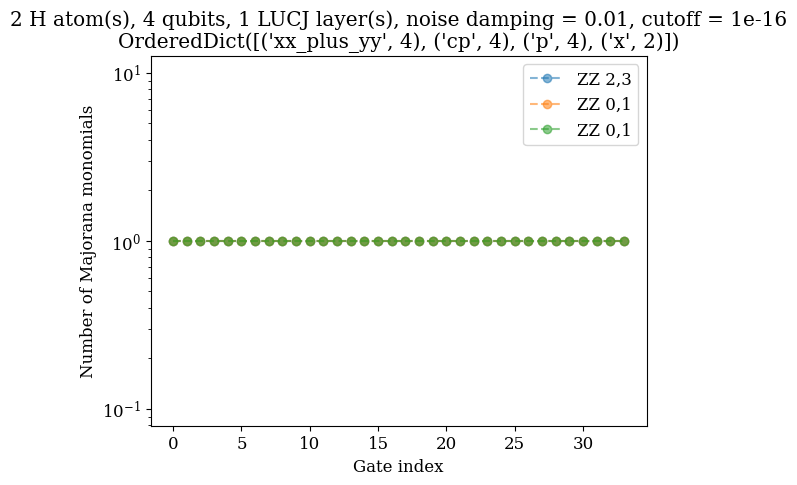

In [22]:
for i, result in enumerate(results):
    plt.semilogy(result.n_terms, "--o", alpha=0.55,label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Gate index")
plt.ylabel("Number of Majorana monomials")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s), noise damping = {damping}, cutoff = {cutoff}\n{compiled.count_ops()}")
plt.legend();

### Pauli basis

In [23]:
pc = PauliCircuit.from_qiskit(compiled.copy())

In [24]:
pauli = PauliPropagator(
    UniformNoiseModel(damping=damping),
    TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
    n_threads=16,
    progress_bar=True,
)

In [25]:
pauli_results = []
for observable in observables:
    observable_mts = PauliTermSum.from_sparse_pauli_op(observable)
    pauli_results.append(pauli.expectation_value(observable_mts, pc, fock_state=0))
    print(pauli_results[-1].expectation_value)

/tmp/ipykernel_520120/332024483.py:4: UserWarning: propaq: the progress bar term count stays stale between truncation flushes. Reduce `truncation_threshold` for more frequent updates.
  pauli_results.append(pauli.expectation_value(observable_mts, pc, fock_state=0))
Propagating through gates: 100%|██████████| 34/34 [00:00<00:00, 82.48it/s, terms=1]  


0.835270211411272


Propagating through gates: 100%|██████████| 34/34 [00:00<00:00, 61.22it/s, terms=1] 


0.835270211411272


Propagating through gates: 100%|██████████| 34/34 [00:00<00:00, 84.69it/s, terms=1] 

0.835270211411272


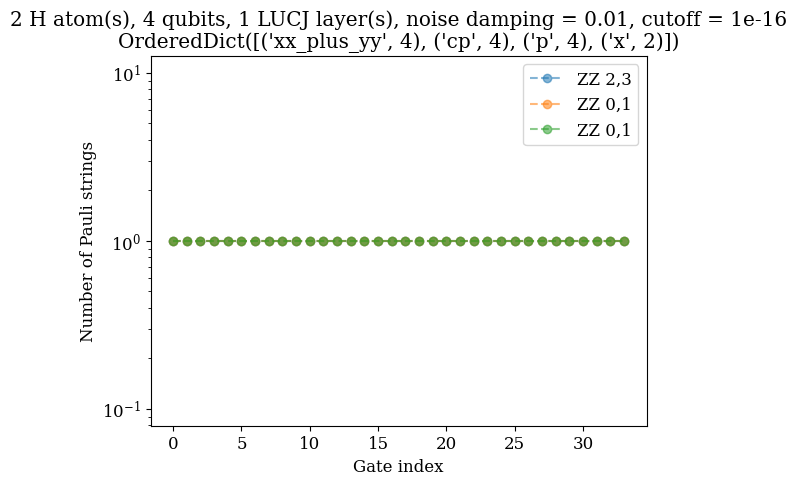

In [26]:
for i, result in enumerate(pauli_results):
    plt.semilogy(result.n_terms, "--o", alpha=0.55,label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Gate index")
plt.ylabel("Number of Pauli strings")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s), noise damping = {damping}, cutoff = {cutoff}\n{compiled.count_ops()}")
plt.legend();